# Selection on pigmentation and sex-hormone genes across primate sexual dichromatism

**A reproducible analysis notebook.** This notebook runs the complete comparative-genomics
analysis end-to-end from frozen inputs and reports every result and figure in one place.

## What this asks
Across 117 primate species, sexual **dichromatism** (males and females differ in hair
coloration) arose **four independent times** (in Lemuridae, Cebidae, Hylobatidae, and
Cercopithecidae). We test whether the genes controlling **pigmentation** or the genes
controlling **sex-hormone** signalling show a change in the *intensity* of natural
selection in the dichromatic lineages, using HyPhy **RELAX** across a curated 80-gene panel.

## How to read the key statistic
RELAX returns **K** per gene, comparing dichromatic ("foreground") to monochromatic branches:
- **K > 1** → selection **intensified** on dichromatic lineages
- **K < 1** → selection **relaxed**
- **K = 1** → no change

A gene is only counted as a hit if it (a) passes a Benjamini-Hochberg multiple-testing
correction (p_BH < 0.05) **and** (b) clears a quality-control gate that rejects alignment
artifacts. Roughly half of the raw "significant" genes are artifacts — this notebook shows
both the raw and the certified result so the filtering is transparent.

## Reproducibility model
- **Run-from-frozen (default):** every cell below runs against the frozen CSV/JSON files in
  `data/`, which are the committed outputs of the cluster RELAX run. No cluster access,
  no heavy compute, no network needed. This regenerates every number and figure.
- **Regenerate-from-scratch (optional):** see `README.md` for how to reproduce the frozen
  inputs themselves — download the genomes, extract CDS, align, and run RELAX/aBSREL on an
  HPC cluster, and how to obtain the species tree independently (Open Tree of Life) rather
  than relying on the bundled copy.

*All results here are from the v3 analysis run (per-sequence outlier removal + 30%-gap
column trimming).*

### How to read this notebook

A few terms used throughout:

- **RELAX / K** — RELAX (a HyPhy method) asks whether natural selection on a gene is *stronger*
  or *weaker* in one set of lineages than another. It returns a single number, **K**, the
  selection-intensity parameter: **K > 1** = selection **intensified** in dichromatic lineages,
  **K < 1** = **relaxed**, **K = 1** = no change. Figures plot **log₂ K**, so 0 = no change,
  positive (red) = intensified, negative (blue) = relaxed.
- **BH-significant** — significant after Benjamini–Hochberg correction for testing many genes
  (controls the false-discovery rate). We report BH-corrected p-values (`p_BH`).
- **Certified hit** — a gene that is both BH-significant *and* passes every alignment-quality
  gate in Section 2. A raw significant p-value is not enough (Section 2 explains why).
- **Foreground** — the 24 dichromatic species; RELAX compares selection on these against the
  other 93. Dichromatism is coded at two levels (**complete**, 9 species; **partial**, 15),
  pooled for the primary test.

Every figure below carries a caption that states its finding in words; you should not need the
code or the surrounding text to read a figure.

In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
import networkx as nx
from pathlib import Path
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)

DATA = Path("data")          # frozen inputs
FIG  = Path("figures"); FIG.mkdir(exist_ok=True)
print("inputs:", sorted(p.name for p in DATA.glob("*")))

inputs: ['absrel', 'alignment_qc.csv', 'dichromatism_coding.csv', 'fit_health.csv', 'gene_panel.csv', 'hormone_axes.csv', 'opentree_independent_tree.nwk', 'pigmentation_network_edges.csv', 'pigmentation_network_nodes.csv', 'primate_species_tree.nex', 'relax_results.csv', 'summary.json', 'tip_roster.csv', 'v3_certification.csv']


## 1. Load the frozen inputs

- `dichromatism_coding.csv` — our phenotype coding: which species we call dichromatic, at
  two levels (`complete` / `partial`). The **primary analysis uses all 24 dichromatic
  species** (`dichromatic == 1`, i.e. complete + partial pooled). The `dichromatism_level`
  column supports a complete-only sensitivity analysis. This coding is ours; it can be
  cross-validated against published dichromatism assessments later.
- `relax_results.csv` — per-gene RELAX K, p-value, BH-corrected p.
- `fit_health.csv` — per-gene QC (gap %, tree length, alignment/reference length ratio, flags).
- `gene_panel.csv` — the 80 genes and their set membership (pigmentation / hormone).
- `primate_species_tree.nex` — the dated primate species tree (topology used for the analysis).

In [2]:
coding = pd.read_csv(DATA/"dichromatism_coding.csv")
relax  = pd.read_csv(DATA/"relax_results.csv")
fit    = pd.read_csv(DATA/"fit_health.csv")
panel  = pd.read_csv(DATA/"gene_panel.csv")

print("species coded:", len(coding),
      "| dichromatic:", int(coding.dichromatic.sum()),
      "(complete=%d, partial=%d)" % ((coding.dichromatism_level=='complete').sum(),
                                      (coding.dichromatism_level=='partial').sum()))
print("dichromatic species by family:")
print(coding[coding.dichromatic==1].family.value_counts().to_string())
print("\ngenes fitted by RELAX:", len(relax), "| panel size:", len(panel))
coding[coding.dichromatic==1][["species","family","dichromatism_level"]].reset_index(drop=True)

species coded: 117 | dichromatic: 24 (complete=9, partial=15)
dichromatic species by family:
family
cercopithecidae    14
hylobatidae         5
lemuridae           3
cebidae             2

genes fitted by RELAX: 77 | panel size: 80


## 2. The QC gate — why raw significance is not enough

RELAX can report a significant K for the wrong reasons: a few misaligned or paralogous
sequences inflate branch lengths, a truncated CDS extraction shortens the alignment
relative to the reference protein, or the fit lands on a degenerate boundary (K→0 or K→∞).
We reject any BH-significant gene that trips **any** of these gates:

| Gate | Reject if | Catches |
|---|---|---|
| gap fraction | > 25% | poorly aligned columns |
| K degenerate | K > 10 or K < 1e-3 | boundary / non-identifiable fits |
| foreground size | < 3 dichromatic tips | underpowered single-branch fits |
| tree length | > 50 subs/site | branch-length blow-up (misalignment) |
| alignment/reference ratio | < 0.8 or > 1.2 | truncated or inflated CDS extraction |

The `aln_ref_ratio` gate is the most important addition: it rejects genes like TYR whose
alignment is only ~65% of the reference protein length — a truncated extraction that
otherwise masquerades as strong intensification.

In [3]:
QC = dict(GAP_MAX=25.0, K_HI=10.0, K_LO=1e-3, FG_MIN=3, TREELEN_MAX=50.0,
          RATIO_LO=0.8, RATIO_HI=1.2)
fitx = fit.set_index("gene")

def qc_reasons(gene, K):
    f = fitx.loc[gene]; r = []
    if f.pct_gaps    > QC["GAP_MAX"]:                    r.append(f"gaps={f.pct_gaps:.0f}%")
    if K > QC["K_HI"]:                                   r.append(f"K={K:.0f}(deg)")
    if K < QC["K_LO"]:                                   r.append("K~0(boundary)")
    if f.n_fg        < QC["FG_MIN"]:                     r.append(f"fg={int(f.n_fg)}")
    if f.tree_len    > QC["TREELEN_MAX"]:                r.append(f"tree_len={f.tree_len:.0f}")
    if not (QC["RATIO_LO"] <= f.aln_ref_ratio <= QC["RATIO_HI"]):
        r.append(f"aln/ref={f.aln_ref_ratio:.2f}")
    return r

sig = relax[relax.p_BH < 0.05].copy()
sig["direction"]   = np.where(sig.K > 1, "intensified", "relaxed")
sig["fail_reason"] = [";".join(qc_reasons(g, k)) for g, k in zip(sig.gene, sig.K)]
sig["certified"]   = sig.fail_reason == ""
sig = sig.sort_values(["certified","set","p_BH"], ascending=[False,True,True])

print(f"BH-significant genes: {len(sig)}")
print(f"  certified (pass QC): {sig.certified.sum()}")
print(f"  rejected as artifact: {(~sig.certified).sum()}")
sig[["gene","set","K","direction","p_BH","certified","fail_reason"]].reset_index(drop=True)

BH-significant genes: 17
  certified (pass QC): 9
  rejected as artifact: 8


### 2.1 The certified hits

These survive both BH-correction and every QC gate.

In [4]:
cert = sig[sig.certified].copy()
print("Certified hits by set:", cert.set.value_counts().to_dict())
print()
for s in ["pigmentation","hormone"]:
    sub = cert[cert.set==s]
    print(f"{s.upper()} ({len(sub)}):")
    for _,r in sub.iterrows():
        flag = fitx.loc[r.gene,"flags"]
        note = "" if flag=="clean" else f"  (cluster flag: {flag})"
        print(f"  {r.gene:9s} K={r.K:5.2f}  {r.direction:11s} p_BH={r.p_BH:.4g}{note}")
    print()

Certified hits by set: {'hormone': 6, 'pigmentation': 3}

PIGMENTATION (3):
  TFAP2A    K= 1.93  intensified p_BH=0.0001
  KITLG     K= 1.30  intensified p_BH=0.0015
  EDN3      K= 1.28  intensified p_BH=0.0015  (cluster flag: branch_len_blowup)

HORMONE (6):
  HSD17B1   K= 2.93  intensified p_BH=0
  HSD17B12  K= 2.52  intensified p_BH=0
  SRD5A1    K= 2.32  intensified p_BH=0  (cluster flag: gaps_gt_20pct)
  CYP7B1    K= 1.37  intensified p_BH=0.0078
  SHBG      K= 0.24  relaxed     p_BH=0.0293
  HSD17B7   K= 1.32  intensified p_BH=0.0402



## 3. Figure 1 — the certified selection result

A lollipop of every BH-significant gene by log2 K, split by gene set, with certified hits
solid and QC-rejected genes shown as grey ×. K=1 (no change) is the dashed center line.

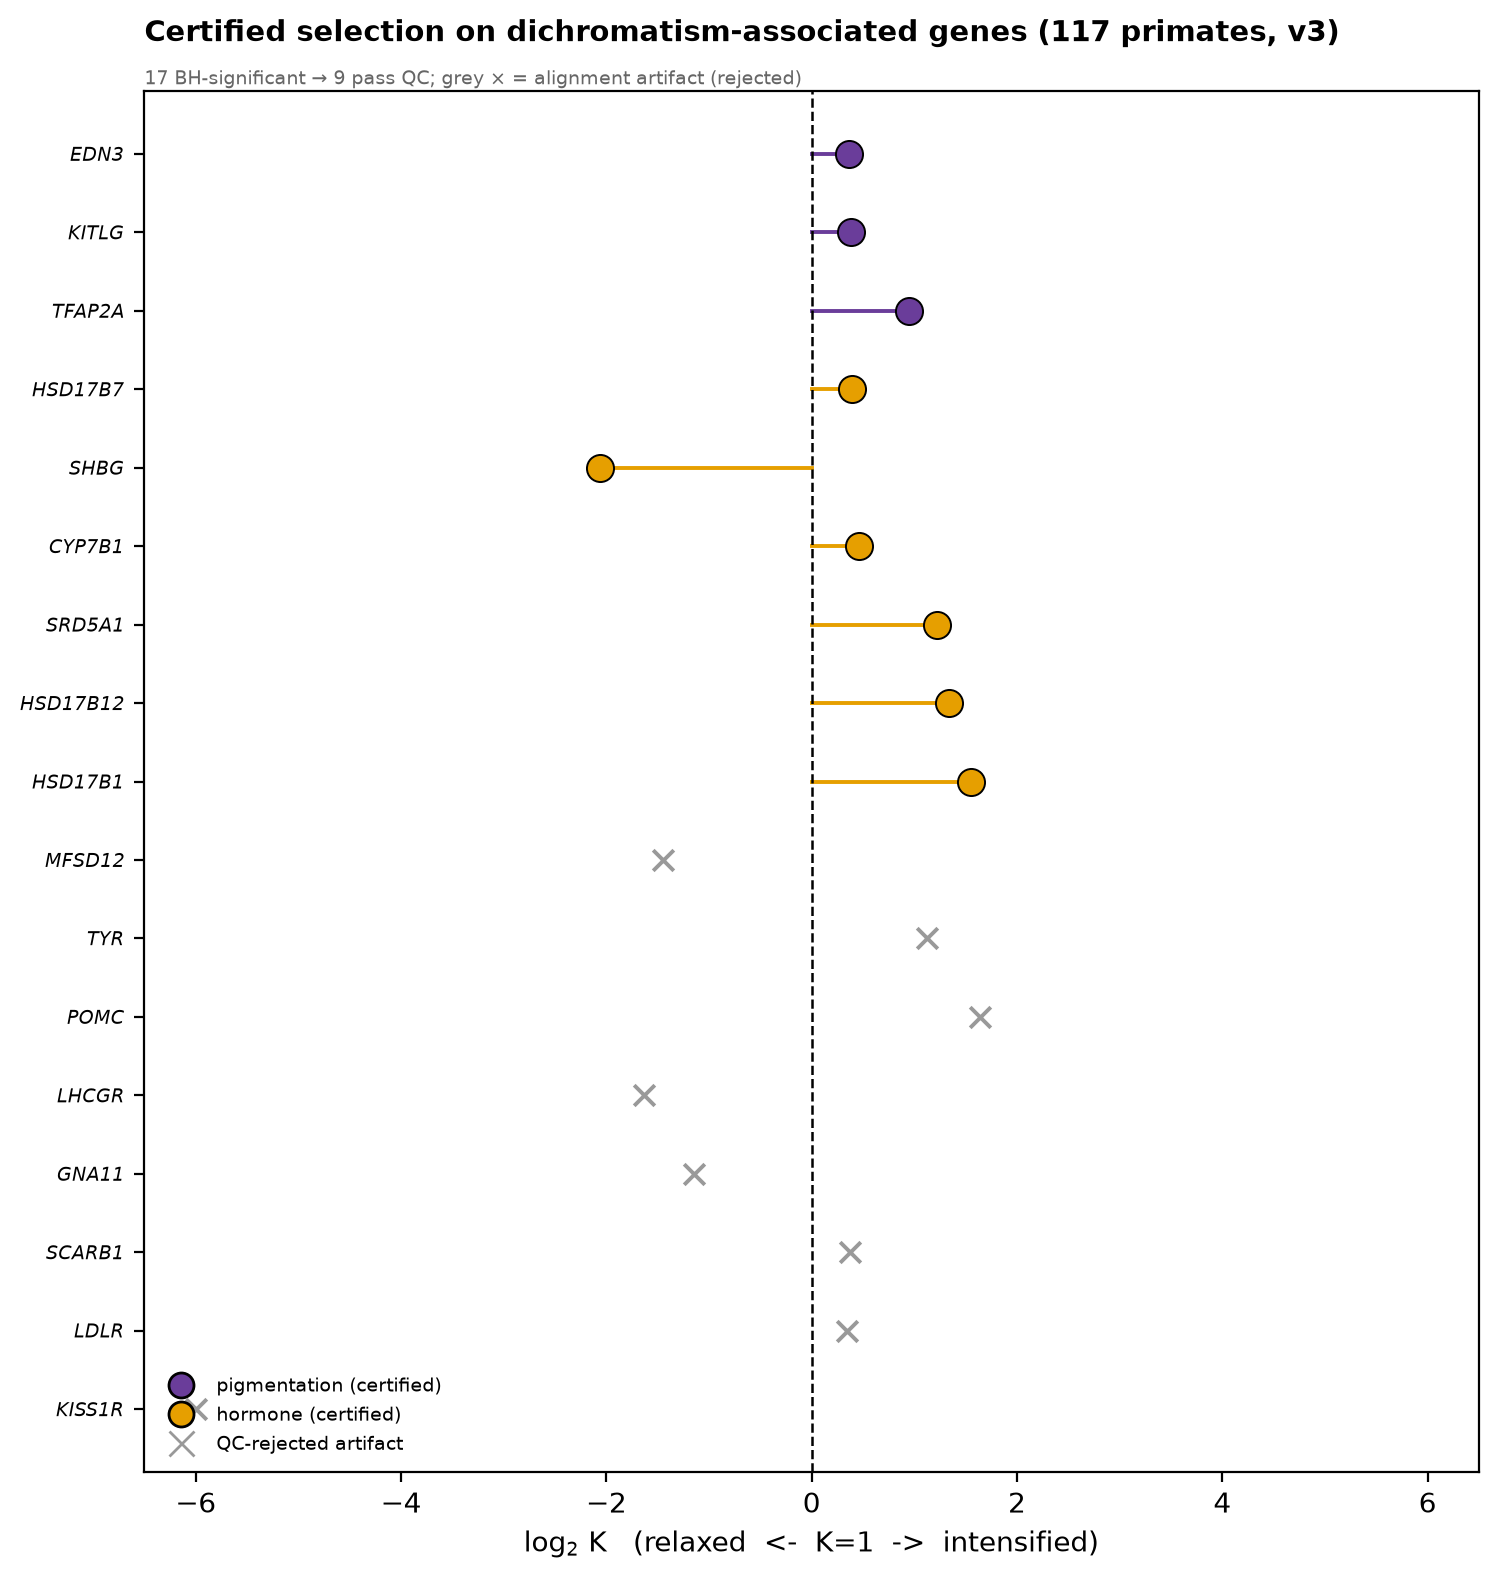

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 8))
PIG, HOR = "#6A3D9A", "#E69F00"   # purple / orange — NOT red/blue (which mean K-direction elsewhere)
d = sig.copy().reset_index(drop=True)
d["log2K"] = np.log2(d.K.clip(lower=1e-6))
d = d.sort_values(["certified","set","p_BH"], ascending=[True,True,True]).reset_index(drop=True)
y = np.arange(len(d))
for yi,(_,r) in zip(y, d.iterrows()):
    col = PIG if r.set=="pigmentation" else HOR
    if r.certified:
        ax.plot([0, r.log2K],[yi,yi], color=col, lw=1.4, zorder=1)
        ax.scatter(r.log2K, yi, s=95, color=col, edgecolor="k", lw=0.7, zorder=3)
    else:
        ax.scatter(np.clip(r.log2K,-6,6), yi, s=55, marker="x", color="#999", lw=1.4, zorder=2)
ax.axvline(0, color="k", lw=0.9, ls="--")
ax.set_yticks(y); ax.set_yticklabels([f"$\\it{{{g}}}$" for g in d.gene], fontsize=7)
ax.set_xlabel("log$_2$ K   (relaxed  <-  K=1  ->  intensified)")
ax.set_xlim(-6.5, 6.5)
ax.set_title("Certified selection on dichromatism-associated genes (117 primates, v3)",
             loc="left", fontweight="bold", fontsize=10.5, pad=18)
n_cert = d.certified.sum()
ax.text(0.0, 1.005, f"{len(d)} BH-significant \u2192 {n_cert} pass QC; grey \u00d7 = alignment artifact (rejected)",
        transform=ax.transAxes, fontsize=7, color="0.4", ha="left")
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([],[],marker="o",color="w",markerfacecolor=PIG,markeredgecolor="k",label="pigmentation (certified)",ls="",ms=9),
    Line2D([],[],marker="o",color="w",markerfacecolor=HOR,markeredgecolor="k",label="hormone (certified)",ls="",ms=9),
    Line2D([],[],marker="x",color="#999",label="QC-rejected artifact",ls="",ms=9)],
    loc="lower left", frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(FIG/"fig1_certified_selection.png", dpi=200, bbox_inches="tight")
plt.show()

**Figure 1.** Of 17 genes significant after multiple-testing correction, 9 pass alignment QC (colored; grey × = rejected artifact). Position on the x-axis is log₂ K — right of the dashed line = selection intensified in dichromatic lineages, left = relaxed. Pigmentation genes (purple) are all intensified; hormone genes (orange) split between intensified steroid-synthesis enzymes and the strongly relaxed carrier gene SHBG.

## 4. Where the signal sits — two functional modules

The certified hits are not scattered. On the **pigmentation** side they concentrate in the
KITLG–EDN3 melanoblast-signalling axis plus the transcription factor TFAP2A. On the
**hormone** side they are steroid-metabolism enzymes (the HSD17B family, SRD5A1, CYP7B1)
plus SHBG, the sex-hormone carrier — not the hormone receptors. Selection targets the
*metabolic/developmental machinery* on both sides.

The pigmentation genes live in a curated interaction network, so we can show them as a graph
painted by K. The hormone genes are a curated *set* (only a few have edges in the pigmentation
network), so they are shown grouped by endocrine axis on the same color scale.

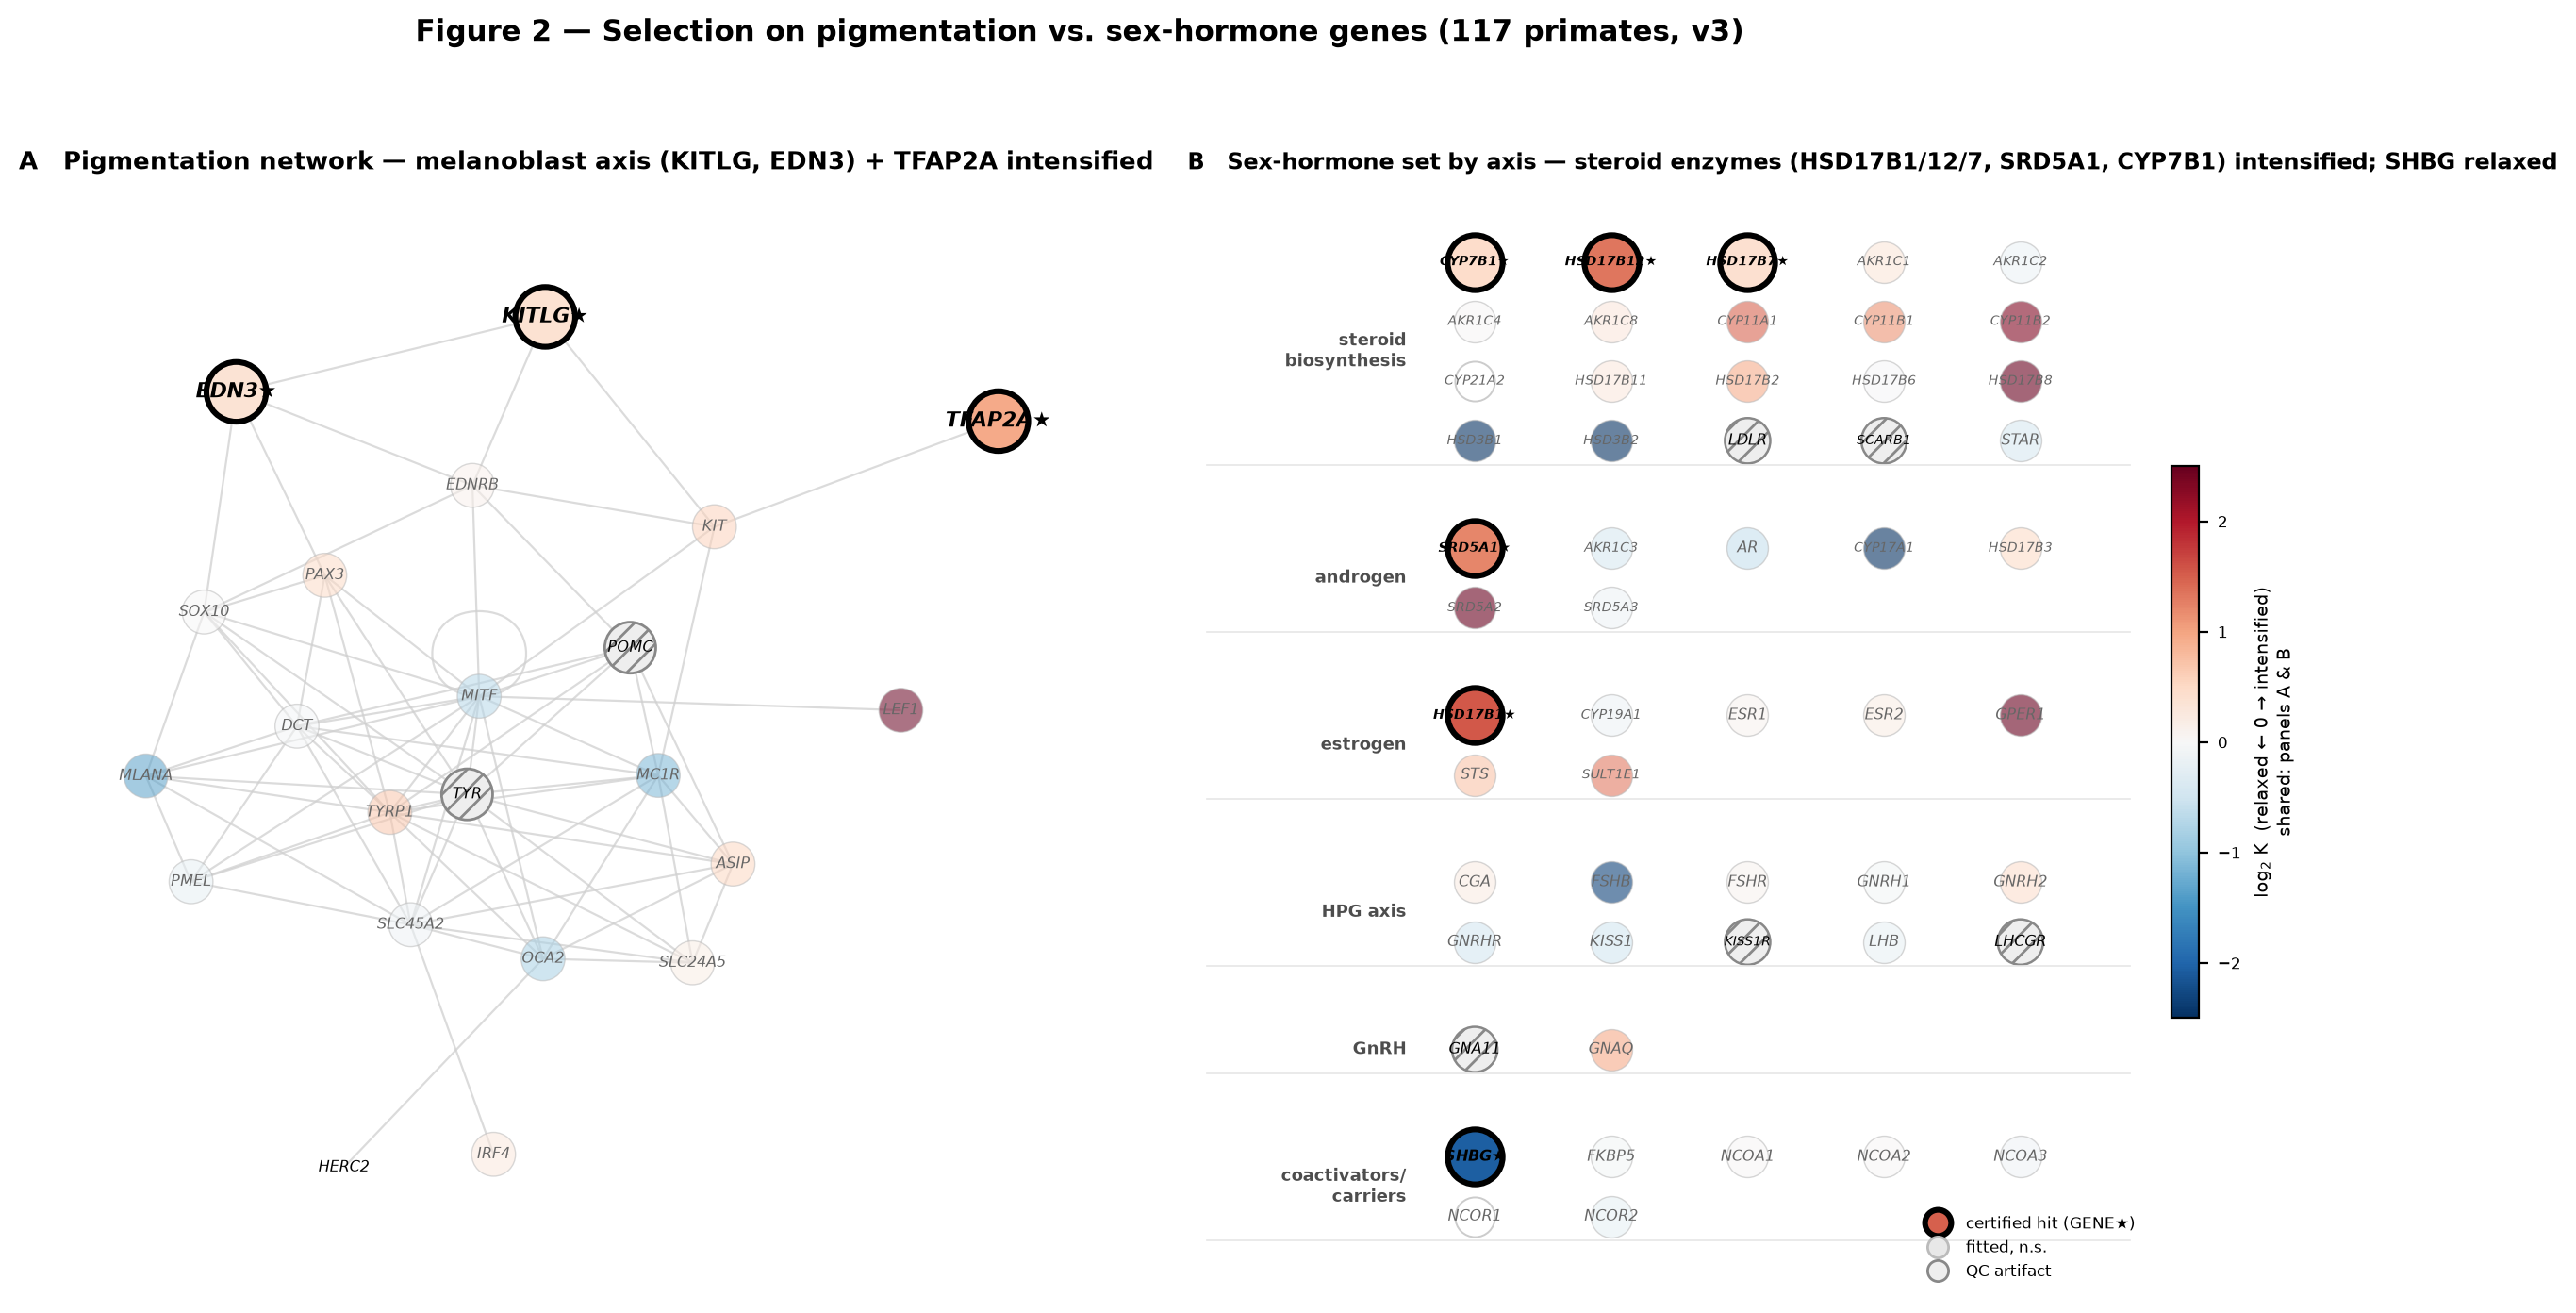

In [6]:
# ---- Figure 2: pigmentation network (painted by K) + hormone set by axis ----
nodes = pd.read_csv(DATA/"pigmentation_network_nodes.csv")
edges = pd.read_csv(DATA/"pigmentation_network_edges.csv")
axes  = pd.read_csv(DATA/"hormone_axes.csv")

relx = relax.set_index("gene")
def gene_paint(g):
    """Return (state, log2K) for a gene. state in {clean_sig, artifact, ns, no_fit}."""
    if g not in relx.index: return ("no_fit", np.nan)
    K = relx.loc[g,"K"]; l2 = np.log2(max(K,1e-6))
    if relx.loc[g,"p_BH"] < 0.05:
        return ("clean_sig" if (g in set(cert.gene)) else "artifact", l2)
    return ("ns", l2)

from matplotlib.colors import TwoSlopeNorm
cmap = plt.get_cmap("RdBu_r"); norm = TwoSlopeNorm(vmin=-2.5, vcenter=0, vmax=2.5)
pig_panel = set(panel.gene[panel.set=="pigmentation"]) & set(nodes.gene)
gcol = ["gene_a","gene_b"] if "gene_a" in edges else ["source","target"]

G = nx.Graph()
for _,e in edges.iterrows():
    if e[gcol[0]] in pig_panel and e[gcol[1]] in pig_panel: G.add_edge(e[gcol[0]], e[gcol[1]])
for g in pig_panel: G.add_node(g)
Gm = G.subgraph(max(nx.connected_components(G), key=len)).copy()
pos = nx.kamada_kawai_layout(Gm)
st  = {g: gene_paint(g) for g in Gm.nodes()}

fig = plt.figure(figsize=(15, 7.6))
gsp = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.06)
axN, axH = fig.add_subplot(gsp[0]), fig.add_subplot(gsp[1])

nx.draw_networkx_edges(Gm, pos, ax=axN, edge_color="#d0d0d0", width=0.8, alpha=0.75)
for state in ["ns","clean_sig"]:
    gg = [g for g in Gm.nodes() if st[g][0]==state]
    if not gg: continue
    axN.scatter([pos[g][0] for g in gg],[pos[g][1] for g in gg],
                s=[520 if state=="clean_sig" else 280 for g in gg],
                c=[cmap(norm(st[g][1])) for g in gg],
                edgecolors=["k" if state=="clean_sig" else "#bbb" for g in gg],
                linewidths=[2.2 if state=="clean_sig" else 0.5 for g in gg],
                alpha=1.0 if state=="clean_sig" else 0.55, zorder=3)
for g in [g for g in Gm.nodes() if st[g][0]=="artifact"]:
    axN.scatter(*pos[g], s=380, facecolor="#eee", edgecolor="#888", hatch="///", lw=1.0, zorder=2)
sigset = set(cert.gene)
for g in Gm.nodes():
    axN.annotate(g+("\u2605" if g in sigset else ""), pos[g], fontsize=8 if g in sigset else 5.8,
                 fontweight="bold" if g in sigset else "normal",
                 ha="center", va="center", fontstyle="italic",
                 color="k" if st[g][0]!="ns" else "#666", zorder=5)
axN.set_title("A   Pigmentation network — melanoblast axis (KITLG, EDN3) + TFAP2A intensified",
              loc="left", fontweight="bold", fontsize=9.5, pad=8)
axN.axis("off"); axN.margins(0.09)

# hormone panel: grouped by axis
axis_order = ["steroid_biosynthesis","androgen_axis","estrogen_axis","hpg_axis",
              "gnrh_signaling","coactivator_corepressor_carrier"]
axis_lab = {"steroid_biosynthesis":"steroid\nbiosynthesis","androgen_axis":"androgen",
            "estrogen_axis":"estrogen","hpg_axis":"HPG axis","gnrh_signaling":"GnRH",
            "coactivator_corepressor_carrier":"coactivators/\ncarriers"}
ax_of = dict(zip(axes.gene, axes.axis_category))
hor_genes = list(axes.gene)
yrow=0; ypos={}; bands=[]
for a in axis_order:
    gl = sorted([g for g in hor_genes if ax_of.get(g)==a],
                key=lambda g:(g not in sigset, g)); y0=yrow
    for i,g in enumerate(gl):
        ypos[g]=(0.6+(i%5)*1.9, -(yrow+i//5))
    yrow += (len(gl)-1)//5 + 1; bands.append((a,y0,yrow-1)); yrow += 0.8
for g,(x,y) in ypos.items():
    s = gene_paint(g)[0]
    if s=="artifact":
        axH.scatter(x,y,s=300,facecolor="#eee",edgecolor="#888",hatch="///",lw=0.9,zorder=2)
    elif s=="no_fit":
        axH.scatter(x,y,s=230,facecolor="white",edgecolor="#ccc",lw=0.7,zorder=2)
    else:
        axH.scatter(x,y,s=440 if s=="clean_sig" else 250, c=[cmap(norm(gene_paint(g)[1]))],
                    edgecolor="k" if s=="clean_sig" else "#bbb",
                    lw=2.2 if s=="clean_sig" else 0.5, alpha=1.0 if s=="clean_sig" else 0.6, zorder=3)
    axH.annotate(g+("\u2605" if g in sigset else ""),(x,y),fontsize=5.0 if len(g)>5 else 5.6,
                 fontweight="bold" if g in sigset else "normal",
                 ha="center",va="center",fontstyle="italic",
                 color="k" if s in ("clean_sig","artifact") else "#666",zorder=5)
for a,y0,y1 in bands:
    axH.text(-0.35,-(y0+y1)/2, axis_lab[a], fontsize=6.6, ha="right", va="center",
             fontweight="bold", color="0.3")
    axH.axhline(-(y1+0.4), xmin=0.02, xmax=0.98, color="0.9", lw=0.6)
axH.set_ylim(-(yrow-0.5),1.2); axH.set_xlim(-3.4,10)
axH.set_title("B   Sex-hormone set by axis — steroid enzymes (HSD17B1/12/7, SRD5A1, CYP7B1) intensified; SHBG relaxed",
              loc="left", fontweight="bold", fontsize=8.6, pad=8)
axH.axis("off")
sm=mpl.cm.ScalarMappable(norm=norm,cmap=cmap); sm.set_array([])
cb=fig.colorbar(sm,ax=[axN,axH],fraction=0.018,pad=0.01,shrink=0.5)
cb.set_label("log$_2$ K  (relaxed \u2190 0 \u2192 intensified)\nshared: panels A & B",fontsize=7); cb.ax.tick_params(labelsize=6)
axH.legend(handles=[
    Line2D([],[],marker="o",color="w",markerfacecolor="#d6604d",markeredgecolor="k",markeredgewidth=2.2,label="certified hit (GENE\u2605)",ls="",ms=10),
    Line2D([],[],marker="o",color="w",markerfacecolor="#e8e8e8",markeredgecolor="#bbb",label="fitted, n.s.",ls="",ms=8),
    Line2D([],[],marker="o",color="w",markerfacecolor="#eee",markeredgecolor="#888",label="QC artifact",ls="",ms=8)],
    loc="lower right", frameon=False, fontsize=6, ncol=1)
fig.suptitle("Figure 2 — Selection on pigmentation vs. sex-hormone genes (117 primates, v3)",
             fontsize=11, fontweight="bold", y=1.0)
fig.savefig(FIG/"fig2_two_networks.png", dpi=200, bbox_inches="tight"); plt.show()

**Figure 2. (A)** The pigmentation gene-interaction network, node colour = log₂ K (red = intensified, blue = relaxed selection in dichromatic lineages). Certified hits (KITLG★, EDN3★, TFAP2A★) carry a heavy black ring; hatched-grey nodes are QC artifacts, not signal. **(B)** Sex-hormone genes grouped by endocrine axis: steroid-biosynthesis enzymes (CYP7B1★, HSD17B12★, HSD17B1★, SRD5A1★) are intensified while the sex-hormone carrier SHBG★ is relaxed. Colour scale is shared between panels.

## 5. Figure 3 — the four independent origins

The phylogeny shows why the design has power: dichromatism (red) arose independently in four
clades. A convergence-based test gains power from independent origins, not raw species count.

dichromatic species by family:
family
cercopithecidae    14
hylobatidae         5
lemuridae           3
cebidae             2


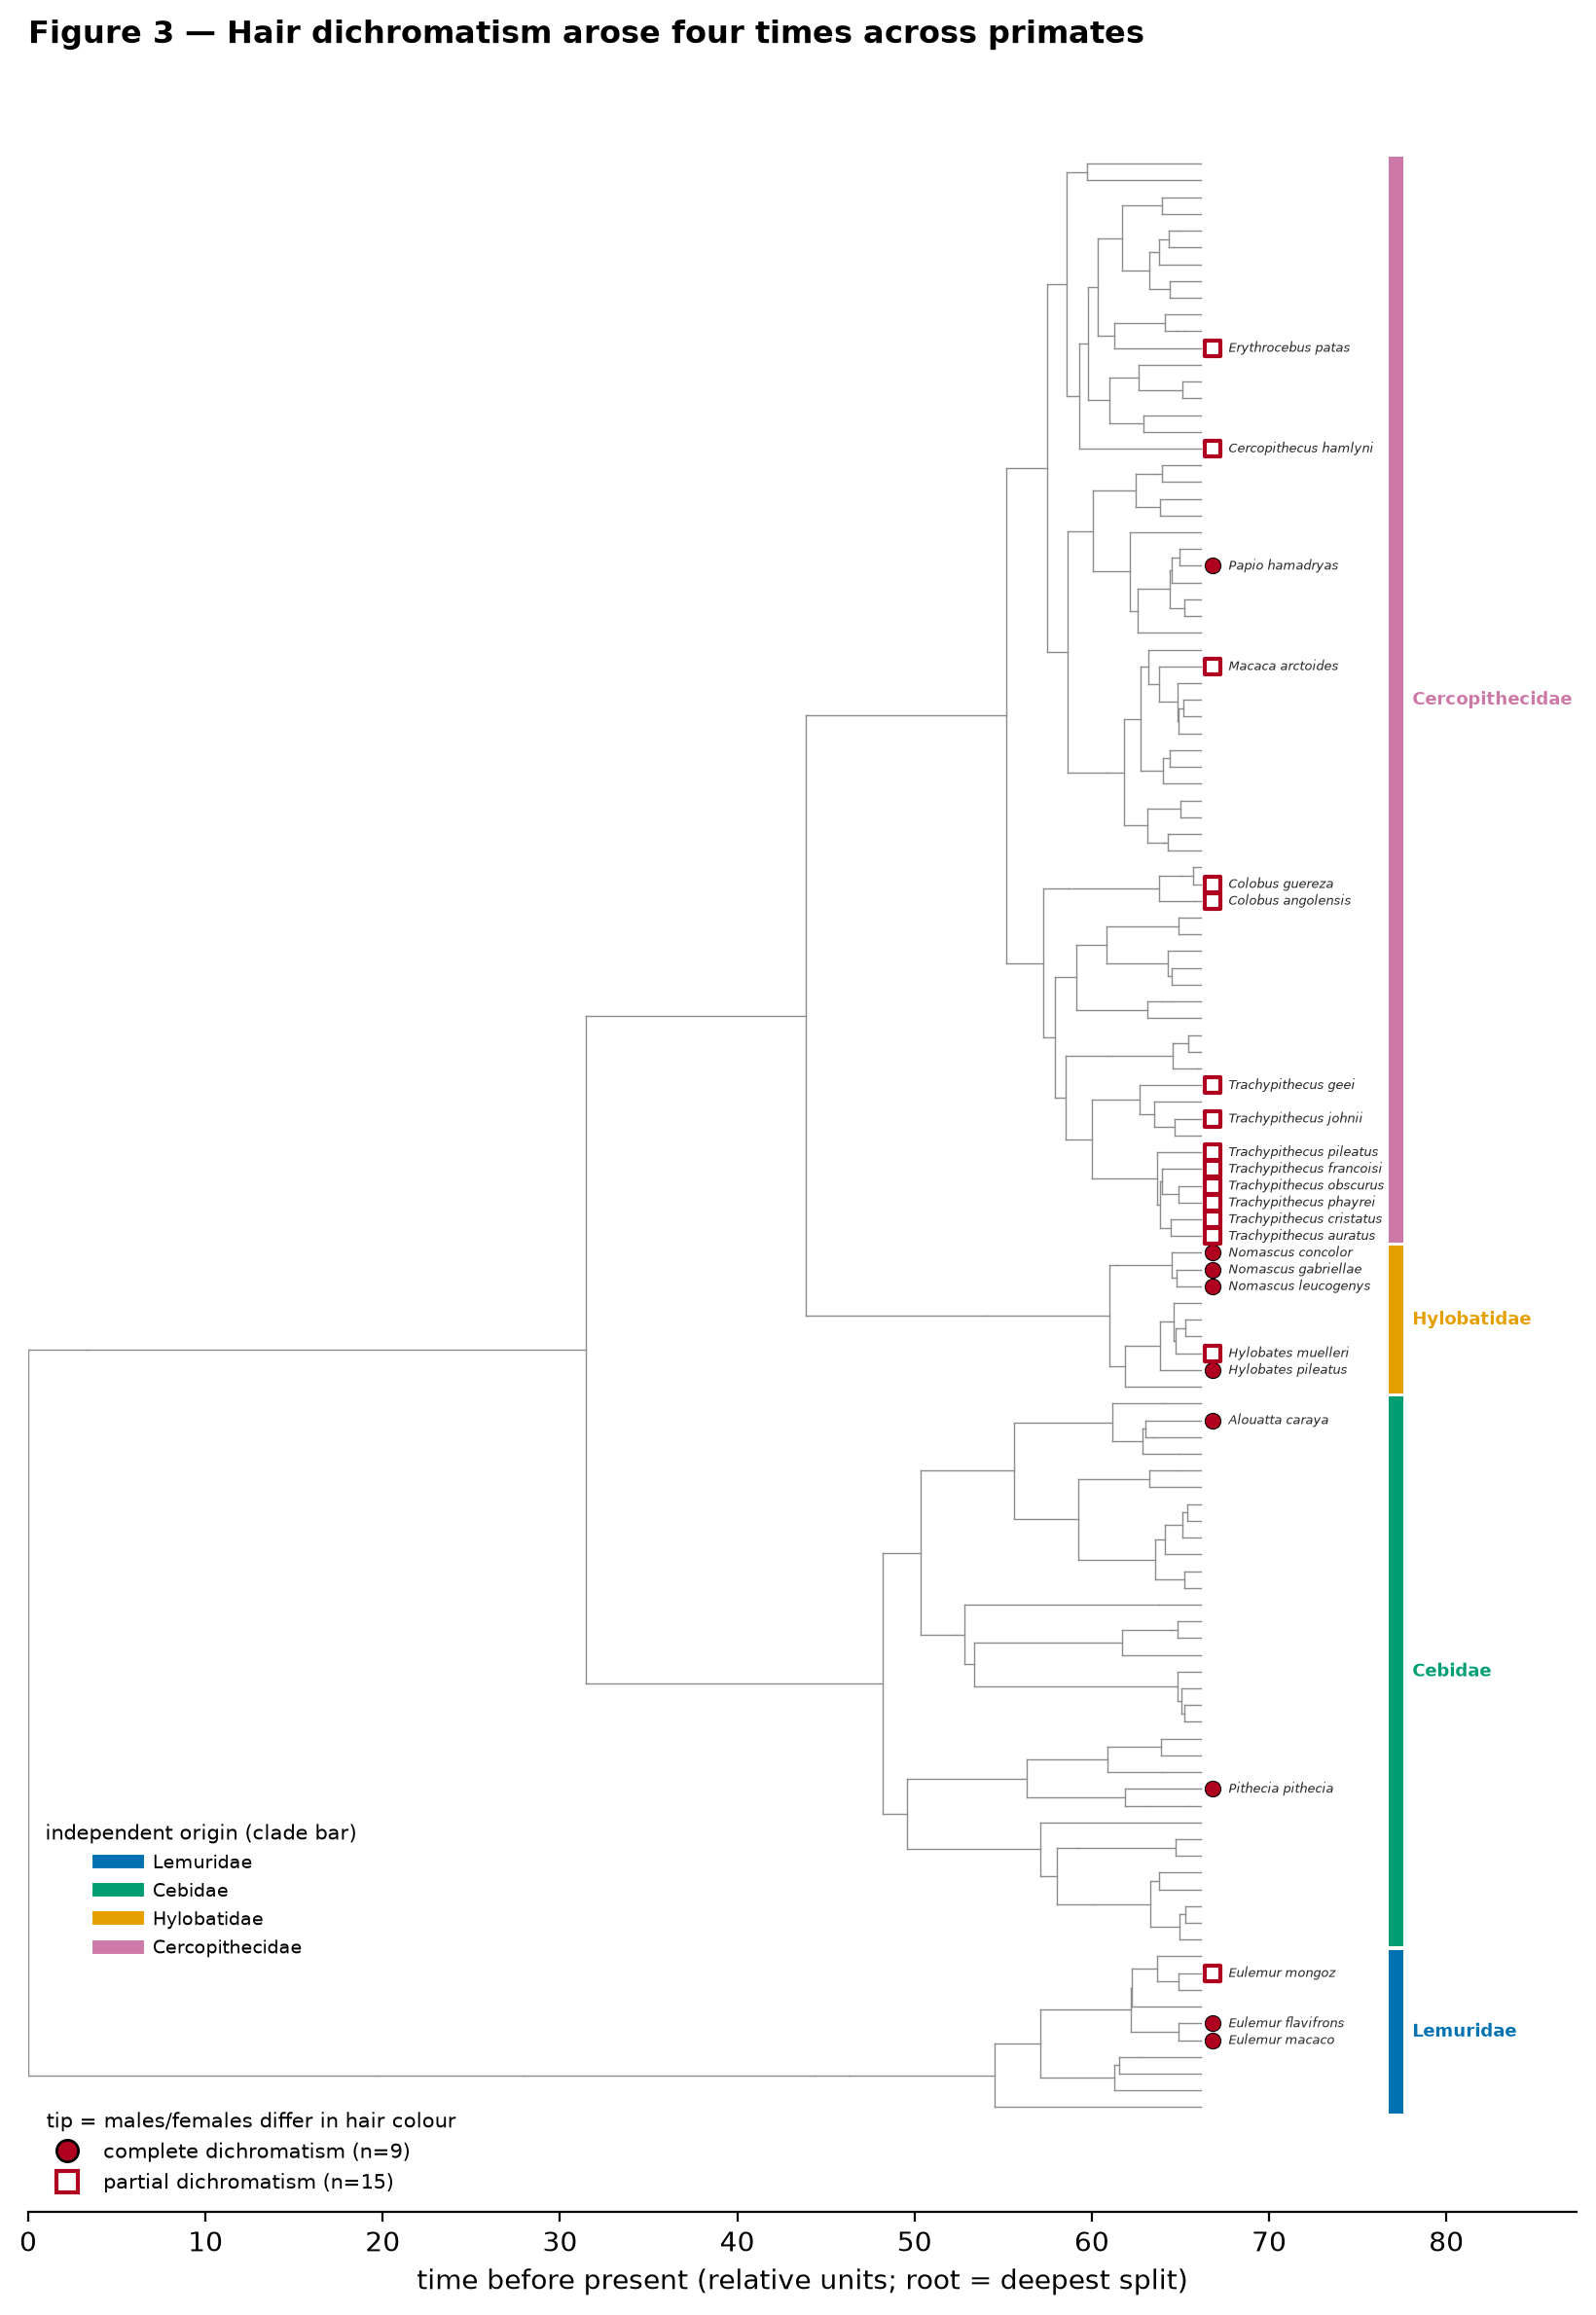

In [7]:
# ---- Figure 3: four independent origins (dependency-free newick renderer) ----
import re
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
def parse_newick(s):
    """Minimal newick -> nested dict {name, children, blen}."""
    s=s.strip().rstrip(";"); pos=[0]
    def rd():
        node={"name":"","children":[],"blen":0.0}
        if s[pos[0]]=="(":
            pos[0]+=1
            while True:
                node["children"].append(rd())
                if s[pos[0]]==",": pos[0]+=1; continue
                if s[pos[0]]==")": pos[0]+=1; break
        m=re.match(r"[^,():;]*", s[pos[0]:]); nm=m.group(0); pos[0]+=len(nm)
        if ":" in nm:
            node["name"],b=nm.split(":",1); node["blen"]=float(b)
        else:
            node["name"]=nm
        if s[pos[0]:pos[0]+1]==":":
            m=re.match(r":([0-9.eE+-]+)", s[pos[0]:]); node["blen"]=float(m.group(1)); pos[0]+=len(m.group(0))
        return node
    return rd()

nexus = (DATA/"primate_species_tree.nex").read_text()
mtree = re.search(r"tree[^=]*=\s*(?:\[[^\]]*\]\s*)?([^;]+;)", nexus, re.I)
nwk_raw = mtree.group(1)
tm = re.search(r"translate(.*?);", nexus, re.I|re.S)
trans = dict(re.findall(r"\s+(\d+)\s+([A-Za-z_][\w]*)", tm.group(1))) if tm else {}
root = parse_newick(nwk_raw)
def relabel(n):
    if not n["children"] and n["name"] in trans: n["name"]=trans[n["name"]]
    for c in n["children"]: relabel(c)
relabel(root)
keep=set(coding.species)
def prune_keep(n):
    if not n["children"]: return n["name"] in keep
    n["children"]=[c for c in n["children"] if prune_keep(c)]
    return len(n["children"])>0
prune_keep(root)
tips=[]
def collect(n):
    if not n["children"]: tips.append(n)
    for c in n["children"]: collect(c)
collect(root)
yid={id(t):i for i,t in enumerate(tips)}
def yof(n):
    return yid[id(n)] if not n["children"] else float(np.mean([yof(c) for c in n["children"]]))
xpos={}
def xof(n,acc=0.0):
    xpos[id(n)]=acc
    for c in n["children"]: xof(c, acc+c["blen"])
xof(root)

dich_set=set(coding.species[coding.dichromatic==1]); level_of=dict(zip(coding.species,coding.dichromatism_level))
fam_of=dict(zip(coding.species,coding.family))
fig,ax=plt.subplots(figsize=(8.4,12))
def draw_edges(n):
    if n["children"]:
        ys=[yof(c) for c in n["children"]]
        ax.plot([xpos[id(n)]]*2,[min(ys),max(ys)],color="0.55",lw=0.5)
        for c in n["children"]:
            ax.plot([xpos[id(n)],xpos[id(c)]],[yof(c),yof(c)],color="0.55",lw=0.5)
            draw_edges(c)
draw_edges(root)
xmax=max(xpos.values())

# --- tip markers: two independent, redundant channels for the 2-level phenotype ---
# complete  = SOLID red circle ; partial = HOLLOW red square (outline only)
RED="#B00020"
for t in tips:
    nm=t["name"]; yy=yof(t)
    if nm in dich_set:
        lvl=level_of.get(nm,"partial")
        if lvl=="complete":
            ax.scatter(xmax*1.01, yy, s=34, marker="o", color=RED, edgecolor="k",
                       lw=0.4, zorder=5, clip_on=False)
        else:  # partial -> hollow square
            ax.scatter(xmax*1.01, yy, s=34, marker="s", facecolor="white", edgecolor=RED,
                       lw=1.5, zorder=5, clip_on=False)
        ax.annotate(" "+nm.replace("_"," "),(xmax*1.02,yy),fontsize=4.8,va="center",
                    fontstyle="italic",color="0.15",annotation_clip=False)

# --- phytools-style clade bars for the 4 independent origins (Okabe-Ito, never red) ---
origins={"Lemuridae":"#0072B2","Cebidae":"#009E73","Hylobatidae":"#E69F00","Cercopithecidae":"#CC79A7"}
xbar=xmax*1.16
for fam,col in origins.items():
    ys=[yof(t) for t in tips if str(fam_of.get(t["name"],"")).lower()==fam.lower()]
    if not ys: continue
    ax.add_patch(Rectangle((xbar,min(ys)-0.4),xmax*0.012,(max(ys)-min(ys))+0.8,
                 facecolor=col,edgecolor="none",clip_on=False,zorder=6))
    ax.annotate(fam,(xbar+xmax*0.02,np.mean(ys)),fontsize=6.5,va="center",ha="left",
                color=col,fontweight="bold",annotation_clip=False)

ax.set_title("Figure 3 — Hair dichromatism arose four times across primates",
             loc="left",fontweight="bold",fontsize=11.5)
ax.set_yticks([]); ax.spines[["top","right","left"]].set_visible(False)
ax.set_xlabel("time before present (relative units; root = deepest split)")
ax.set_xlim(0, xmax*1.32)
leg1=ax.legend(handles=[
        Line2D([],[],marker="o",color="w",markerfacecolor=RED,markeredgecolor="k",label="complete dichromatism (n=9)",ls="",ms=8),
        Line2D([],[],marker="s",color="w",markerfacecolor="white",markeredgecolor=RED,markeredgewidth=1.5,label="partial dichromatism (n=15)",ls="",ms=8)],
    loc="lower left",frameon=False,fontsize=7.5,title="tip = males/females differ in hair colour",title_fontsize=7.5)
leg1._legend_box.align="left"
ax.add_artist(leg1)
ax.legend(handles=[Line2D([],[],color=c,lw=5,label=f) for f,c in origins.items()],
          loc="lower left",bbox_to_anchor=(0,0.11),frameon=False,fontsize=7,
          title="independent origin (clade bar)",title_fontsize=7.5)
fig.tight_layout(); fig.savefig(FIG/"fig3_tree.png",dpi=200,bbox_inches="tight"); plt.show()
print("dichromatic species by family:")
print(coding[coding.dichromatic==1].family.value_counts().to_string())

**Figure 3.** Hair dichromatism (males and females differ in coat colour) arose independently in four primate clades — marked by coloured clade bars. Tip symbols: solid red circle = complete dichromatism (9 species); hollow red square = partial (15 species). The four independent origins are what give the convergence-based selection test its power.

## 6. Set-level test — is the pigmentation set different from the hormone set?

The per-gene hits are suggestive, but the project's core question is a **set-level** contrast:
as a group, do pigmentation genes show different selection than hormone genes? We use a
SUMSTAT-style signed score (sign(K−1)·−log10 p) per QC-passing gene and test the
pigmentation-vs-hormone difference with a 100,000-iteration label permutation.

In [8]:
rng = np.random.default_rng(0)
q = sig.copy()  # start from BH-sig; but SUMSTAT should use ALL QC-passing fitted genes, not just BH-sig
# recompute over the full fitted panel with QC gate
full = relax.copy()
full["reason"] = [";".join(qc_reasons(g,k)) for g,k in zip(full.gene, full.K)]
full = full[full.reason==""].copy()
full["score"] = np.sign(full.K-1) * -np.log10(full.p_value.clip(lower=1e-300))
pig = full.score[full.set=="pigmentation"].values
hor = full.score[full.set=="hormone"].values
obs = pig.mean() - hor.mean()
pool = np.concatenate([pig,hor]); npig=len(pig)
perm = np.array([ (lambda s: s[:npig].mean()-s[npig:].mean())(rng.permutation(pool)) for _ in range(100000)])
p_perm = (np.abs(perm) >= abs(obs)).mean()
from scipy.stats import ranksums
w = ranksums(pig,hor)
print(f"QC-passing genes: pigmentation={npig}, hormone={len(hor)}")
print(f"mean signed score: pigmentation={pig.mean():+.3f}, hormone={hor.mean():+.3f}")
print(f"observed difference (pig-hor): {obs:+.3f}")
print(f"permutation p (100k): {p_perm:.4f}")
print(f"Wilcoxon rank-sum p:  {w.pvalue:.4f}")
print()
print("INTERPRETATION:", "no significant set-level difference" if p_perm>=0.05
      else "significant set-level difference")

QC-passing genes: pigmentation=11, hormone=26
mean signed score: pigmentation=+1.203, hormone=+1.042
observed difference (pig-hor): +0.161
permutation p (100k): 0.8747
Wilcoxon rank-sum p:  0.1950

INTERPRETATION: no significant set-level difference


## 7. Integrating the network: are the hits a module, or three unrelated genes?

The pigmentation "hits" mean much more if they form a **connected functional unit** than if
they are scattered across the pathway. Two distinct questions:

1. **Descriptive (does the network reveal a module?):** are the certified pigmentation hits
   directly connected in the curated pigmentation network? — This is what turns a gene list
   into a mechanistic story.
2. **Inferential (does topology *predict* selection?):** is selection intensity (K)
   assortative on the network — i.e., do interacting genes have correlated K? — A stronger
   claim that would say connectivity itself shapes where selection acts.

We report both. The descriptive link is real and is the basis for the "melanoblast
module" interpretation. The inferential claim is **not** supported (assortativity is
non-significant), so we make no claim that connectivity drives selection — the network's role
here is to *identify* the module, not to *explain* the selection statistic.

In [9]:
import networkx as nx
# --- rebuild the pigmentation network on fitted genes ---
enodes = pd.read_csv(DATA/"pigmentation_network_nodes.csv")
eedges = pd.read_csv(DATA/"pigmentation_network_edges.csv")
gA, gB = ("gene_a","gene_b") if "gene_a" in eedges else ("source","target")
Gfull = nx.Graph()
for _,e in eedges.iterrows(): Gfull.add_edge(e[gA], e[gB])

cert_pig = list(cert.gene[cert.set=="pigmentation"])
print("Certified pigmentation hits:", cert_pig)

# (1) DESCRIPTIVE: direct connectivity among the hits + their route to the master regulators
module_genes = cert_pig + ["KIT","EDNRB","SOX10","MITF"]
Gmod = Gfull.subgraph([g for g in module_genes if g in Gfull]).copy()
print("\nEdges among the melanoblast-module genes (hits + KIT/EDNRB/SOX10/MITF):")
for a,b in sorted(Gmod.edges()):
    if a!=b: print(f"   {a} — {b}")
for i in range(len(cert_pig)):
    for j in range(i+1,len(cert_pig)):
        a,b=cert_pig[i],cert_pig[j]
        if a in Gfull and b in Gfull:
            try: print(f"\n   shortest path {a}–{b}: {' -> '.join(nx.shortest_path(Gfull,a,b))}")
            except nx.NetworkXNoPath: print(f"   {a},{b}: no path")

# (2) INFERENTIAL: assortativity of log2 K across the fitted pigmentation subnetwork
relx = relax.set_index("gene")
pig_fitted = [g for g in panel.gene[panel.set=="pigmentation"] if g in Gfull and g in relx.index]
Gp = Gfull.subgraph(pig_fitted).copy()
for g in Gp.nodes(): Gp.nodes[g]["l2k"] = float(np.log2(max(relx.loc[g,"K"],1e-6)))
r_assort = nx.numeric_assortativity_coefficient(Gp,"l2k")
rng = np.random.default_rng(42)
vals = np.array([Gp.nodes[g]["l2k"] for g in Gp.nodes()]); nl=list(Gp.nodes())
def _assort(v):
    nx.set_node_attributes(Gp,{n:x for n,x in zip(nl,v)},"t"); return nx.numeric_assortativity_coefficient(Gp,"t")
null = np.array([_assort(rng.permutation(vals)) for _ in range(5000)])
p_assort = (np.abs(null) >= abs(r_assort)).mean()
print(f"\nAssortativity of log2 K on pigmentation network: r = {r_assort:.3f}, permutation p = {p_assort:.3f}")
print("INTERPRETATION:", "topology does NOT predict selection intensity (as expected for a"
      " distributed, polygenic signal) — network identifies the module, does not explain K." if p_assort>=0.05
      else "topology predicts selection intensity")

Certified pigmentation hits: ['TFAP2A', 'KITLG', 'EDN3']

Edges among the melanoblast-module genes (hits + KIT/EDNRB/SOX10/MITF):
   EDN3 — KITLG
   EDN3 — SOX10
   EDNRB — EDN3
   EDNRB — KIT
   EDNRB — KITLG
   EDNRB — MITF
   EDNRB — SOX10
   KIT — KITLG
   KIT — MITF
   MITF — SOX10
   TFAP2A — KIT

   shortest path TFAP2A–KITLG: TFAP2A -> KIT -> KITLG

   shortest path TFAP2A–EDN3: TFAP2A -> JUN -> EDN1 -> EDN3

   shortest path KITLG–EDN3: KITLG -> EDN3

Assortativity of log2 K on pigmentation network: r = -0.100, permutation p = 0.272
INTERPRETATION: topology does NOT predict selection intensity (as expected for a distributed, polygenic signal) — network identifies the module, does not explain K.


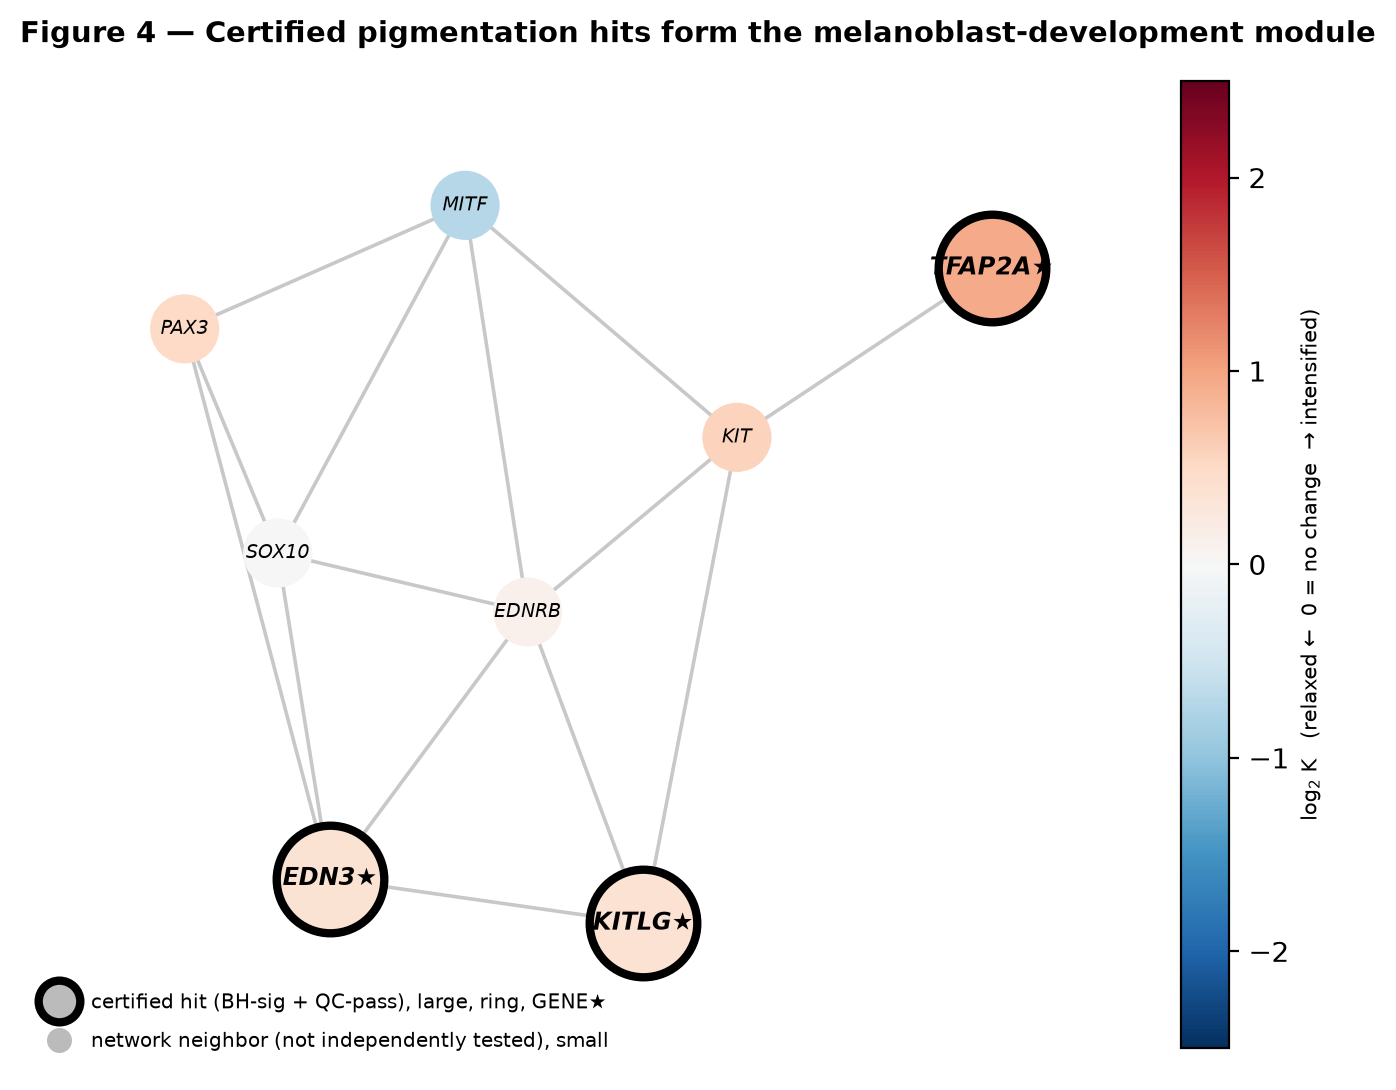

In [10]:
# --- Figure 4: the melanoblast module, drawn from the network, colored by selection K ---
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
cmap = plt.get_cmap("RdBu_r"); norm = TwoSlopeNorm(vmin=-2.5, vcenter=0, vmax=2.5)
Gmod2 = Gfull.subgraph([g for g in (cert_pig+["KIT","EDNRB","SOX10","MITF","PAX3"]) if g in Gfull]).copy()
Gmod2.remove_edges_from(nx.selfloop_edges(Gmod2))
pos = nx.kamada_kawai_layout(Gmod2) if len(Gmod2)>2 else nx.spring_layout(Gmod2, seed=1)
fig, ax = plt.subplots(figsize=(7.8, 6.4))
nx.draw_networkx_edges(Gmod2, pos, ax=ax, edge_color="#c8c8c8", width=1.3)
certset = set(cert_pig)
# certified hit vs neighbor now read on THREE redundant channels:
#   (1) outline PRESENCE (heavy black ring) vs ABSENCE, (2) size, (3) a star after the label.
for g in Gmod2.nodes():
    K = relx.loc[g,"K"] if g in relx.index else 1.0
    l2 = np.log2(max(K,1e-6))
    is_hit = g in certset
    if is_hit:
        ax.scatter(*pos[g], s=1500, c=[cmap(norm(l2))], edgecolor="k", linewidths=3.0, zorder=4)
    else:
        ax.scatter(*pos[g], s=620, c=[cmap(norm(l2))], edgecolor="none", zorder=3)
    label = g+"\u2605" if is_hit else g
    ax.annotate(label, pos[g], fontsize=8.5 if is_hit else 7.0,
                fontweight="bold" if is_hit else "normal",
                ha="center", va="center", fontstyle="italic", zorder=5)
ax.set_title("Figure 4 — Certified pigmentation hits form the melanoblast-development module",
             loc="left", fontweight="bold", fontsize=10.5)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
cb.set_label("log$_2$ K   (relaxed \u2190  0 = no change  \u2192 intensified)", fontsize=7.5)
cb.set_ticks([-2,-1,0,1,2])
ax.legend(handles=[
    Line2D([],[],marker="o",color="w",markerfacecolor="#bbb",markeredgecolor="k",markeredgewidth=3.0,label="certified hit (BH-sig + QC-pass), large, ring, GENE\u2605",ls="",ms=15),
    Line2D([],[],marker="o",color="w",markerfacecolor="#bbb",markeredgecolor="none",label="network neighbor (not independently tested), small",ls="",ms=9)],
    loc="lower left", frameon=False, fontsize=7.3, handletextpad=0.6, labelspacing=0.9)
ax.axis("off"); ax.margins(0.14)
fig.subplots_adjust(top=0.90)
fig.savefig(FIG/"fig4_module.png", dpi=200, bbox_inches="tight"); plt.show()

**Figure 4.** The three certified pigmentation hits (KITLG★, EDN3★, TFAP2A★; heavy black ring, larger nodes) are not scattered — they sit one interaction step from the SOX10/MITF melanocyte hub via EDNRB, forming a single melanoblast-development module. Node colour = log₂ K (red = intensified selection). Small unringed nodes are untested network neighbours shown for context.

## 8. Summary of findings

**The network makes it one story, not two.** The three certified pigmentation hits are not scattered — KITLG and EDN3 are direct interaction partners, and with TFAP2A they converge on SOX10/MITF via EDNRB (Figure 4). The pigmentation network is what reveals the hits as a single **melanoblast-development module** rather than three unrelated genes. (Network topology does *not* predict selection intensity — assortativity of K is non-significant — so we claim only that the network *identifies* the module, not that connectivity *drives* selection.)

**Robust result (certified, v3):** selection intensity changes in dichromatic primate
lineages, and the signal spans **both** networks:

- **Pigmentation:** TFAP2A, KITLG, EDN3 — the melanoblast-signalling axis and its
  transcription factor, all *intensified*. (KIT was significant in an earlier run but
  drops to non-significant after per-sequence outlier removal — a reminder that these are
  interim numbers.)
- **Hormone:** the steroid-metabolism enzymes HSD17B1, HSD17B12, HSD17B7, SRD5A1, CYP7B1
  (all *intensified*) plus SHBG (the carrier, *relaxed*). Notably **not** the hormone
  receptors — selection targets metabolism, not reception.

**Contrast with the classic bird result:** In galliform birds (Nadeau et al. 2007), the
dichromatism signal was specific to MC1R, the melanocortin switch. In primates MC1R is not
the hit — the pigmentation signal sits at a *different node* (melanoblast development). This
is a genuine cross-taxon divergence in the molecular architecture of dichromatism.

**Caveats:**
1. The formal pigmentation-vs-hormone **set-level contrast is not yet significant**
   (permutation p ≈ 0.87) — with the current gene counts we cannot claim one network is more
   affected than the other. The headline is "selection targets specific modules in
   *both* networks," not "one network wins."
2. About half of the raw BH-significant genes are alignment artifacts, rejected by QC. The
   figures flag these explicitly (grey ×/hatched); they must not be read as findings.
3. RELAX detects a distributed *shift in selection intensity* across the dichromatic
   foreground, not dramatic positive selection on individual branches (aBSREL finds few
   individual dichromatic branches under episodic selection) — the expected signature for a
   polygenic trait.
4. Foreground = 24 species coded dichromatic (`hair_dichromatism_any`). A complete-only
   (9-species) sensitivity analysis can be run from `dichromatism_coding.csv` by filtering
   `dichromatism_level == "complete"`.

*This is an interim analysis; numbers may shift with further alignment refinement.*

In [11]:
# Save a machine-readable summary of the certified result
out = cert[["gene","set","K","direction","p_BH"]].copy()
out["flag"] = [fitx.loc[g,"flags"] for g in out.gene]
out.to_csv("certified_hits.csv", index=False)
print("wrote certified_hits.csv")
print(f"\nCERTIFIED HITS: {len(out)} ({out.set.value_counts().to_dict()})")
print(f"set-level contrast: not yet significant (interim)")
out.reset_index(drop=True)

wrote certified_hits.csv

CERTIFIED HITS: 9 ({'hormone': 6, 'pigmentation': 3})
set-level contrast: not yet significant (interim)
